In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# Ignore  the warnings
import warnings
warnings.filterwarnings('always')
warnings.filterwarnings('ignore')

In [4]:
!pip install tensorflow_addons

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 611.8/611.8 kB 3.6 MB/s eta 0:00:00


In [6]:
# data visualisation and manipulation
import numpy as np, pandas as pd, re, matplotlib.pyplot as plt, seaborn as sns, math, random

from matplotlib import style
from collections import Counter

#configure
# sets matplotlib to inline and displays graphs below the corressponding cell.
%matplotlib inline
style.use('fivethirtyeight')
sns.set(style='whitegrid',color_codes=True)

#model selection
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold, GridSearchCV
from sklearn.metrics import accuracy_score,precision_score, recall_score,confusion_matrix,roc_curve,roc_auc_score
from sklearn.preprocessing import LabelEncoder

#preprocess.
from keras.preprocessing.image import ImageDataGenerator

#dl libraraies
import tensorflow as tf
import tensorflow_addons as tfa
from keras import backend as K
from keras.models import Sequential, load_model
from keras.layers import Dense, Dropout, Flatten, Activation, BatchNormalization
from keras.optimizers import Adam,SGD,Adagrad,Adadelta,RMSprop
from keras.utils import to_categorical

from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetV2B1 as efnv2b1
import random as rn

# specifically for manipulating zipped images and getting numpy arrays of pixel values of images.
import tqdm, os, glob, tempfile
from random import shuffle
from PIL import Image

In [7]:
class CONFIG:
    HEIGHT = 224
    WIDTH = 224
    SEED = 42
    FOLDS = 5
    IMAGE_SIZES = [224, 224, 224, 224, 224] #same img size for each fold
    BATCH_SIZE = [16] * FOLDS
    EPOCHS = [12] * FOLDS
    WEIGHTS = [1/FOLDS] * FOLDS
    AUTO = tf.data.experimental.AUTOTUNE
    VERBOSE = 1

In [8]:
ROTATION = 180.0
SHEAR = 2.0
H_ZOOM = 8.0
W_ZOOM = 8.0
H_SHIFT = 8.0
W_SHIFT = 8.0

def create_3x3_matrix(list):
    """Reshape a list into a 3x3 matrix."""
    return tf.reshape(tf.concat([list], axis=0), [3, 3])

def compose_transformation_matrix(rotation, shear, height_zoom, width_zoom, height_shift, width_shift):
    """
    Create a composite transformation matrix from rotation, shear, zoom, and shift parameters.
    """
    rotation = math.pi * rotation / 180.0
    shear = math.pi * shear / 180.0

    c1 = tf.math.cos(rotation)
    s1 = tf.math.sin(rotation)
    one = tf.constant([1], dtype='float32')
    zero = tf.constant([0], dtype='float32')

    rotation_matrix = create_3x3_matrix([c1, s1, zero,
                                        -s1, c1, zero,
                                        zero, zero, one])
    c2 = tf.math.cos(shear)
    s2 = tf.math.sin(shear)

    shear_matrix = create_3x3_matrix([one, s2, zero,
                                     zero, c2, zero,
                                     zero, zero, one])
    zoom_matrix = create_3x3_matrix([one / height_zoom, zero, zero,
                                     zero, one / width_zoom, zero,
                                    zero, zero, one])
    shift_matrix = create_3x3_matrix([one, zero, height_shift,
                                     zero, one, width_shift,
                                     zero, zero, one])
    return tf.linalg.matmul(tf.linalg.matmul(rotation_matrix, shear_matrix), tf.linalg.matmul(zoom_matrix, shift_matrix))

def apply_random_transformations(image, dim=224):
    """ Apply random transformations to an image. """
    xdim = dim % 2
    rot = ROTATION * tf.random.normal([1], dtype = 'float32')
    shr = SHEAR * tf.random.normal([1], dtype = 'float32')
    h_zoom = 1.0 + tf.random.normal([1], dtype = 'float32') / H_ZOOM
    w_zoom = 1.0 + tf.random.normal([1], dtype = 'float32') / W_ZOOM
    h_shift = H_SHIFT * tf.random.normal([1], dtype = 'float32')
    w_shift = W_SHIFT * tf.random.normal([1], dtype = 'float32')

    # Get transformation matrix
    m = compose_transformation_matrix(rot, shr, h_zoom, w_zoom, h_shift, w_shift)

    # list destination pixel indices
    x = tf.repeat(tf.range(dim // 2, -dim // 2, -1), dim)
    y = tf.tile(tf.range(-dim // 2, dim // 2), [dim])
    z = tf.ones([dim * dim], dtype = 'int32')
    idx = tf.stack([x, y, z])

    # Rotate destination pixels onto origin pixels
    idx2 = tf.linalg.matmul(m, tf.cast(idx, dtype='float32'))
    idx2 = tf.cast(idx2, dtype = 'int32')
    idx2 = tf.clip_by_value(idx2, -dim //2 + xdim + 1, dim // 2)

    # Find origin pixel values
    idx3 = tf.stack([dim // 2 - idx2[0,], dim // 2 - 1 + idx2[1,]])
    d = tf.gather_nd(image, tf.transpose(idx3))

    return tf.reshape(d, [dim, dim, 3])

In [9]:
def read_labeled_tfrecord(example):
    """ parse a TFRecord example into an image and label. """
    tfrec_format = {
        'image': tf.io.FixedLenFeature([], tf.string),
        'label': tf.io.FixedLenFeature([], tf.float32)
    }
    example = tf.io.parse_single_example(example, tfrec_format)
    image = tf.io.decode_jpeg(example['image'], channels = 3)

    # Normalize the image to [0, 1] range
    image = tf.image.convert_image_dtype(image, tf.float32)

    # Get the label
    label = example['label']

    return image, label

def prepare_image(img, augment = True, dim = 224):
    """ Prepare an image for training or evaluation, with optional augmentation. """
    if augment:
        img = apply_random_transformations(img, dim = dim)
        img = tf.image.random_flip_left_right(img)
        img = tf.image.random_saturation(img, 0.7, 1.3)
        img = tf.image.random_contrast(img, 0.8, 1.2)
        img = tf.image.random_brightness(img, 0.1)

    # Resize the image if necessary
    img = tf.image.resize(img, [dim, dim])

    return img

def count_data_items(file_paths):
    """ Count the total number of items in a list of TFRecord files. """
    total_items = 0
    for file_path in file_paths:
        for record in tf.data.TFRecordDataset(file_path):
            total_items +=1

    return total_items


In [10]:
def get_dataset(files, augment = False, shuffle = False, repeat = False, dim = 224):
    """ Create a TensorFlow dataset from TFRecord files.
    Parameters:
    -files: List of TFRecord files.
    -augment: Boolean, whether to apply data augmentation.
    -shuffle: Boolean, whether to shuffle the dataset.
    -repeat: Boolean, whether to repeat the dataset.
    -labeled: Boolean, whether the TFRecords contain labels.
    Returns:
    - A TensorFlow dataset ready for training or evaluation.
    """
    ds = tf.data.TFRecordDataset(files, num_parallel_reads = tf.data.experimental.AUTOTUNE)
    ds = ds.cache()

    if repeat:
        ds = ds.repeat()
    if shuffle:
        ds = ds.shuffle(1024 * 8)
        opt = tf.data.Options()
        opt.experimental_deterministic = False
        ds = ds.with_options(opt)
    ds = ds.map(read_labeled_tfrecord, num_parallel_calls = tf.data.experimental.AUTOTUNE)
    ds = ds.map(lambda img, label: (prepare_image(img, augment = augment, dim = dim), label), num_parallel_calls = tf.data.experimental.AUTOTUNE)
    ds = ds.prefetch(tf.data.experimental.AUTOTUNE)

    # Convert datasets to arrays for compatibility with Stratified Kfold
    images = []
    labels = []
    for features, label in ds:
        images.append(features.numpy())
        labels.append(label.numpy())
    return np.array(images), np.array(labels)


In [11]:
METRICS = [
    tf.keras.metrics.BinaryCrossentropy(name = 'Cross Entropy'),
    tf.keras.metrics.F1Score(name = 'f1_score'),
    tf.keras.metrics.TruePositives(name = 'TP'),
    tf.keras.metrics.FalsePositives(name = 'FP'),
    tf.keras.metrics.TrueNegatives(name = 'TN'),
    tf.keras.metrics.FalseNegatives(name = 'FN'),
    tf.keras.metrics.BinaryAccuracy(name = 'accuracy'),
    tf.keras.metrics.BinaryAccuracy(name='val_auc'),
    tf.keras.metrics.Precision(name = 'precision'),
    tf.keras.metrics.Recall(name = 'recall'),
    tf.keras.metrics.AUC(name = 'auc'),
    tf.keras.metrics.AUC(name = 'prc', curve = 'PR'), #precision recall curve
]

In [12]:
input_shape = (CONFIG.HEIGHT, CONFIG.WIDTH, 3)
inputs = tf.keras.layers.Input(shape=input_shape)
base_efn = tf.keras.applications.EfficientNetV2B1(
    include_top=False,
    weights='imagenet',
    input_tensor=inputs,
    pooling=None,
    classes=2,
    classifier_activation='sigmoid',
    include_preprocessing=False
)

In [13]:
#NC
def build_model(dim=224):
    model = tf.keras.Sequential([
        base_efn,
        tf.keras.layers.Flatten(),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dense(32, activation = tfa.activations.gelu),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dense(1, activation = 'sigmoid')
    ])
    opt = tf.keras.optimizers.Adam(learning_rate=0.001)
    loss = tf.keras.losses.BinaryCrossentropy(label_smoothing=0.05)
    model.compile(optimizer = opt, loss=loss, metrics = METRICS)
    return model


In [14]:
def get_lr_callback(batch_size = 8):
    """ Creat a learning rate callback with a custom learning rate schedule. """
    lr_start = 0.000005
    lr_max = 0.00000125 * batch_size
    lr_min = 0.000001
    lr_ramp_epochs = 5
    lr_sustain_epochs = 0
    lr_decay = 0.8

    def lrfn(epoch):
        if epoch < lr_ramp_epochs:
            lr = (lr_max - lr_start) / lr_ramp_epochs * epoch + lr_start
        elif epoch < lr_ramp_epochs + lr_sustain_epochs:
            lr = lr_max
        else:
            lr = (lr_max - lr_min) * lr_decay ** (epoch - lr_ramp_epochs - lr_sustain_epochs) + lr_min
        return lr
    lr_callback = tf.keras.callbacks.LearningRateScheduler(lrfn, verbose = 1)
    return lr_callback


#### FOLD 1
Training...

Epoch 1: LearningRateScheduler setting learning rate to 5e-06.
Epoch 1/12
107/107 [==============================] - 96s 267ms/step - loss: 0.8941 - Cross Entropy: 0.8931 - f1_score: 0.3166 - TP: 177.0000 - FP: 691.0000 - TN: 699.0000 - FN: 145.0000 - accuracy: 0.5117 - val_auc: 0.5405 - precision: 0.2039 - recall: 0.5497 - auc: 0.5227 - prc: 0.2013 - val_loss: 0.7760 - val_Cross Entropy: 0.7741 - val_f1_score: 0.3089 - val_TP: 38.0000 - val_FP: 162.0000 - val_TN: 178.0000 - val_FN: 38.0000 - val_accuracy: 0.5192 - val_val_auc: 0.5192 - val_precision: 0.1900 - val_recall: 0.5000 - val_prc: 0.2254 - lr: 5.0000e-06

Epoch 2: LearningRateScheduler setting learning rate to 8.000000000000001e-06.
Epoch 2/12
107/107 [==============================] - 17s 150ms/step - loss: 0.8092 - Cross Entropy: 0.8045 - f1_score: 0.3170 - TP: 194.0000 - FP: 667.0000 - TN: 716.0000 - FN: 127.0000 - accuracy: 0.5340 - val_auc: 0.5605 - precision: 0.2253 - recall: 0.6044 - auc: 0.6153

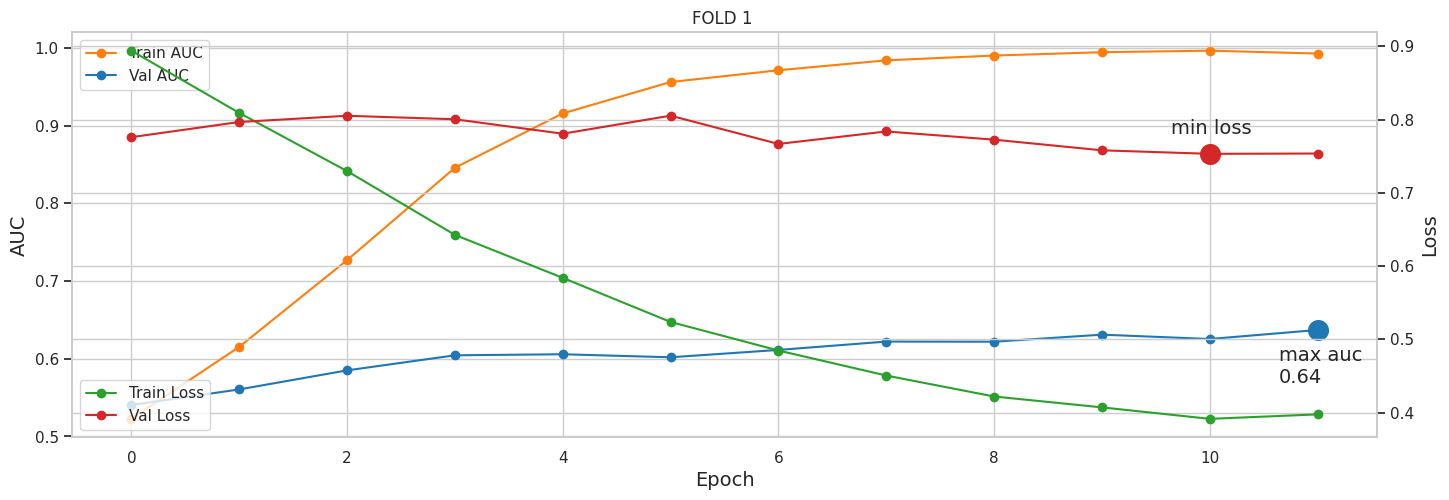

#### FOLD 2
Training...

Epoch 1: LearningRateScheduler setting learning rate to 5e-06.
Epoch 1/12
107/107 [==============================] - 83s 284ms/step - loss: 0.8601 - Cross Entropy: 0.8604 - f1_score: 0.3158 - TP: 156.0000 - FP: 690.0000 - TN: 701.0000 - FN: 165.0000 - accuracy: 0.5006 - val_auc: 0.5418 - precision: 0.1844 - recall: 0.4860 - auc: 0.4906 - prc: 0.1854 - val_loss: 0.7008 - val_Cross Entropy: 0.6963 - val_f1_score: 0.3055 - val_TP: 37.0000 - val_FP: 123.0000 - val_TN: 218.0000 - val_FN: 38.0000 - val_accuracy: 0.6130 - val_val_auc: 0.6130 - val_precision: 0.2313 - val_recall: 0.4933 - val_prc: 0.2053 - lr: 5.0000e-06

Epoch 2: LearningRateScheduler setting learning rate to 8.000000000000001e-06.
Epoch 2/12
107/107 [==============================] - 16s 152ms/step - loss: 0.7636 - Cross Entropy: 0.7593 - f1_score: 0.3154 - TP: 203.0000 - FP: 634.0000 - TN: 751.0000 - FN: 116.0000 - accuracy: 0.5599 - val_auc: 0.5761 - precision: 0.2425 - recall: 0.6364 - auc: 0.6258

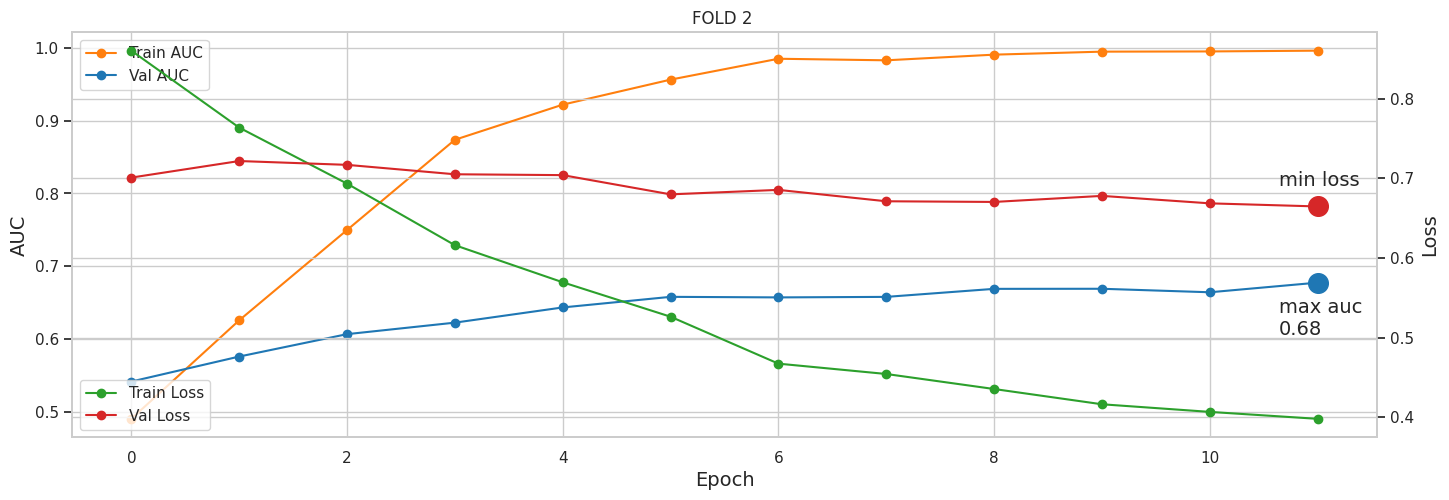

#### FOLD 3
Training...

Epoch 1: LearningRateScheduler setting learning rate to 5e-06.
Epoch 1/12
107/107 [==============================] - 92s 300ms/step - loss: 0.8419 - Cross Entropy: 0.8410 - f1_score: 0.3158 - TP: 172.0000 - FP: 672.0000 - TN: 719.0000 - FN: 149.0000 - accuracy: 0.5204 - val_auc: 0.6243 - precision: 0.2038 - recall: 0.5358 - auc: 0.5309 - prc: 0.2029 - val_loss: 0.7309 - val_Cross Entropy: 0.7282 - val_f1_score: 0.3192 - val_TP: 48.0000 - val_FP: 170.0000 - val_TN: 167.0000 - val_FN: 31.0000 - val_accuracy: 0.5168 - val_val_auc: 0.5168 - val_precision: 0.2202 - val_recall: 0.6076 - val_prc: 0.2748 - lr: 5.0000e-06

Epoch 2: LearningRateScheduler setting learning rate to 8.000000000000001e-06.
Epoch 2/12
107/107 [==============================] - 17s 159ms/step - loss: 0.7490 - Cross Entropy: 0.7428 - f1_score: 0.3162 - TP: 217.0000 - FP: 615.0000 - TN: 769.0000 - FN: 103.0000 - accuracy: 0.5786 - val_auc: 0.6721 - precision: 0.2608 - recall: 0.6781 - auc: 0.6712

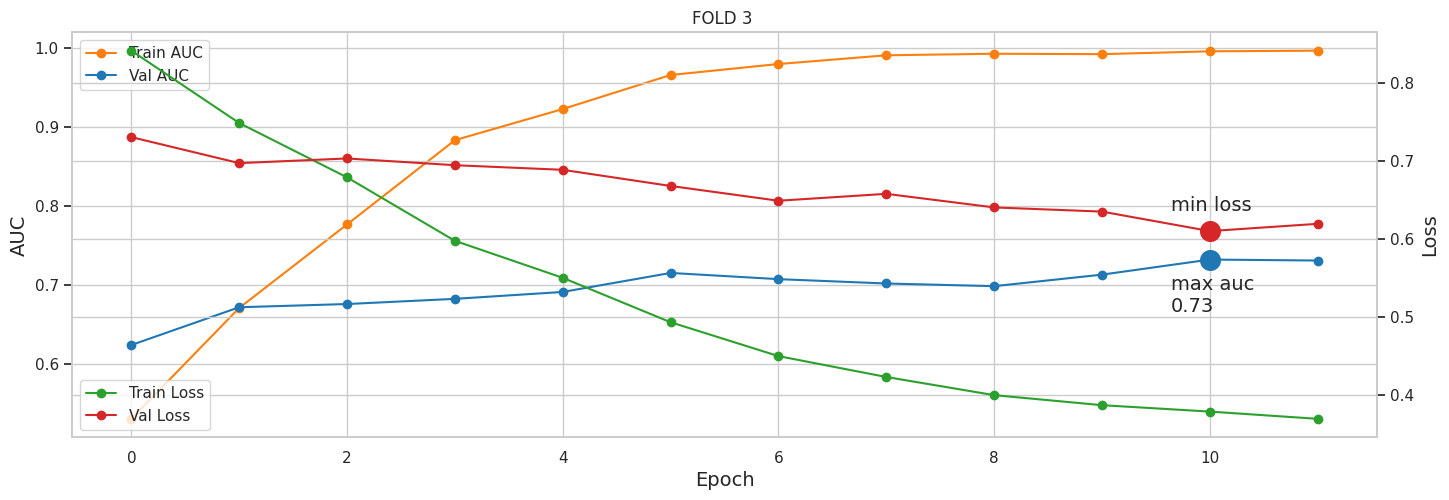

#### FOLD 4
Training...

Epoch 1: LearningRateScheduler setting learning rate to 5e-06.
Epoch 1/12
107/107 [==============================] - 97s 352ms/step - loss: 0.8633 - Cross Entropy: 0.8629 - f1_score: 0.3166 - TP: 159.0000 - FP: 703.0000 - TN: 687.0000 - FN: 163.0000 - accuracy: 0.4942 - val_auc: 0.5502 - precision: 0.1845 - recall: 0.4938 - auc: 0.5092 - prc: 0.1996 - val_loss: 0.7134 - val_Cross Entropy: 0.7091 - val_f1_score: 0.3192 - val_TP: 42.0000 - val_FP: 146.0000 - val_TN: 191.0000 - val_FN: 37.0000 - val_accuracy: 0.5601 - val_val_auc: 0.5601 - val_precision: 0.2234 - val_recall: 0.5316 - val_prc: 0.2414 - lr: 5.0000e-06

Epoch 2: LearningRateScheduler setting learning rate to 8.000000000000001e-06.
Epoch 2/12
107/107 [==============================] - 19s 174ms/step - loss: 0.7819 - Cross Entropy: 0.7766 - f1_score: 0.3145 - TP: 213.0000 - FP: 635.0000 - TN: 751.0000 - FN: 105.0000 - accuracy: 0.5657 - val_auc: 0.6055 - precision: 0.2512 - recall: 0.6698 - auc: 0.6444

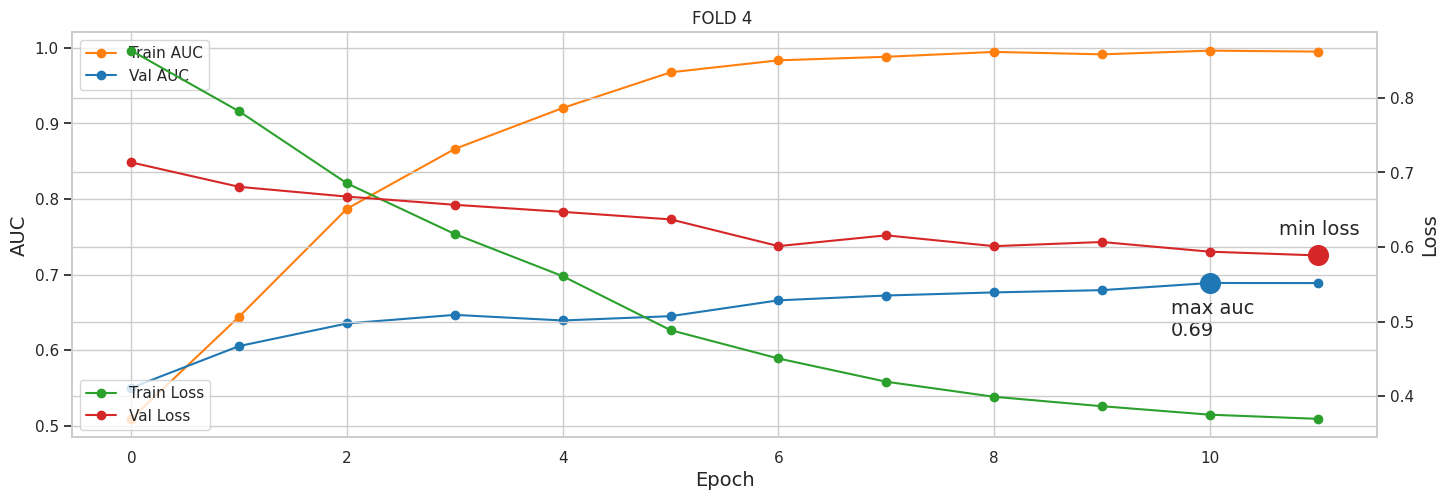

#### FOLD 5


In [ ]:
#Conv2D 64, 32, 16
#NC
VERBOSE = 1
DISPLAY_PLOT = True

#Train Data
tfrec_dir = tf.io.gfile.glob(['../../../dataset/task1/tf_records/train00.tfrec'])
data, labels = get_dataset(tfrec_dir, augment=True, shuffle=True, repeat=False, )

tfrec_test = tf.io.gfile.glob(['../../../dataset/task1/tf_records/test00.tfrec'])
X_test, y_test = get_dataset(tfrec_test, augment=True, shuffle=True, repeat=False, )
preds = np.zeros((count_data_items(tfrec_test),1))

skf = StratifiedKFold(n_splits=CONFIG.FOLDS, shuffle=True, random_state=CONFIG.SEED)
oof_pred = []; oof_tar = []; oof_val = []; oof_names = []; oof_folds = []


for fold,(idxT,idxV) in enumerate(skf.split(data, labels)):

    # DISPLAY FOLD INFO
    print('#### FOLD',fold+1)

    # CREATE TRAIN AND VALIDATION SUBSETS
    train_data, train_labels = data[idxT], labels[idxT]
    val_data, val_labels = data[idxV], labels[idxV]

    #Create Tensorflow Dataset
    train_dataset = tf.data.Dataset.from_tensor_slices((train_data, train_labels))
    val_dataset = tf.data.Dataset.from_tensor_slices((val_data, val_labels))
    #BATCHING, SHUFFLING
    train_dataset = train_dataset.batch(CONFIG.BATCH_SIZE[fold]).repeat()
    val_dataset = val_dataset.batch(CONFIG.BATCH_SIZE[fold])

    num_train_examples = len(train_labels)
    num_val_examples = len(val_labels)


    steps_per_epoch = num_train_examples // CONFIG.BATCH_SIZE[fold]
    validation_steps = num_val_examples // CONFIG.BATCH_SIZE[fold]

    # BUILD MODEL
    K.clear_session()

    model = build_model(dim=224)

    # SAVE BEST MODEL EACH FOLD
    sv = tf.keras.callbacks.ModelCheckpoint(
        filepath = 'efnv2b1_fold-%i.h5'%fold, monitor='val_loss', verbose=0, save_best_only=True,
        save_weights_only=True, mode='min', save_freq='epoch')

    # TRAIN
    print('Training...')
    history = model.fit(
        train_dataset,
        epochs=CONFIG.EPOCHS[fold], callbacks = [sv, get_lr_callback(CONFIG.BATCH_SIZE[fold])],
        validation_data=val_dataset,
        steps_per_epoch = steps_per_epoch, validation_steps = validation_steps,
        verbose=1
    )

    print('Loading best model...')
    model.load_weights('efnv2b1_fold-%i.h5'%fold)

    # PREDICT OOF USING TTA
    print('Predicting OOF with TTA...')
    pred = model.predict(val_dataset, verbose=0)
    oof_pred.append( np.mean(pred, axis=1) )
    #oof_pred.append(model.predict(get_dataset(files_valid,dim=IMG_SIZES[fold]),verbose=1))

    # GET OOF TARGETS AND NAMES

    oof_tar.append( np.array([target.numpy() for img, target in iter(val_dataset.unbatch())]) )
    oof_folds.append( np.ones_like(oof_tar[-1],dtype='int8')*fold )
    ds = val_dataset
    #oof_names.append( np.array([img_name.numpy().decode("utf-8") for img, img_name in iter(ds.unbatch())]))

    # PREDICT TEST USING TTA
    print('Predicting Test with TTA...')
    ds_test = X_test
    ct_test = len(y_test)
    pred = model.predict(ds_test,verbose=0)
    if len(pred.shape) == 2:
    # Ensure preds array has the correct shape
        if preds.shape[1] != pred.shape[1]:
            raise ValueError("Mismatch between preds shape and pred shape")
        preds[:, 0] += np.mean(pred, axis=0)  # Averaging predictions

        # If pred is 1-dimensional, you might want to reshape it or adjust your processing logic
    elif len(pred.shape) == 1:
        # Example adjustment for 1-dimensional pred
        preds[:, 0] += pred  # Assuming pred has same length as preds[:, 0]
    else:
        raise ValueError("Unexpected shape for pred")

    # REPORT RESULTS
    auc = roc_auc_score(oof_tar[-1],oof_pred[-1])
    oof_val.append(np.max( history.history['val_auc'] ))
    print('#### FOLD %i OOF AUC without TTA = %.3f, with TTA = %.3f'%(fold+1,oof_val[-1],auc))

    #Cross Entropy, Confusion Matrix, F1
    results = model.evaluate(X_test, verbose=0)
    for name, value in zip(model.metrics_names, results):
        print(name, ': ', value)

    print()
    # PLOT TRAINING
    if DISPLAY_PLOT:
        plt.figure(figsize=(15,5))
        plt.plot(np.arange(CONFIG.EPOCHS[fold]),history.history['auc'],'-o',label='Train AUC',color='#ff7f0e')
        plt.plot(np.arange(CONFIG.EPOCHS[fold]),history.history['val_auc'],'-o',label='Val AUC',color='#1f77b4')
        x = np.argmax( history.history['val_auc'] ); y = np.max( history.history['val_auc'] )
        xdist = plt.xlim()[1] - plt.xlim()[0]; ydist = plt.ylim()[1] - plt.ylim()[0]
        plt.scatter(x,y,s=200,color='#1f77b4'); plt.text(x-0.03*xdist,y-0.13*ydist,'max auc\n%.2f'%y,size=14)
        plt.ylabel('AUC',size=14); plt.xlabel('Epoch',size=14)
        plt.legend(loc=2)
        plt2 = plt.gca().twinx()
        plt2.plot(np.arange(CONFIG.EPOCHS[fold]),history.history['loss'],'-o',label='Train Loss',color='#2ca02c')
        plt2.plot(np.arange(CONFIG.EPOCHS[fold]),history.history['val_loss'],'-o',label='Val Loss',color='#d62728')
        x = np.argmin( history.history['val_loss'] ); y = np.min( history.history['val_loss'] )
        ydist = plt.ylim()[1] - plt.ylim()[0]
        plt.scatter(x,y,s=200,color='#d62728'); plt.text(x-0.03*xdist,y+0.05*ydist,'min loss',size=14)
        plt.ylabel('Loss',size=14)
        plt.title('FOLD %i '% (fold+1))
        plt.legend(loc=3)
        plt.show()

In [ ]:
def test_evaluate(model, X_test, y_test):
    predictions = model.predict(X_test)
    # Convert predictions to binary (0, 1)
    predicted_labels = (predictions > 0.5).astype(int).flatten()

    # Classification Report
    report = classification_report(y_test, predicted_labels, target_names = ['Class 0', 'Class 1'], output_dict = True)

    # ROC AUC Score
    roc = roc_auc_score(y_test, predictions)
    print(f'ROC AUC Score: {roc}')

    # Confusion Matrix
    cm = confusion_matrix(y_test, predicted_labels)

    # Plot CM
    disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = ['Class 0', 'Class 1'])
    disp.plot()
    plt.show()

    # Metrics
    class_nevus_keratosis = report.get('Class 0', {'precision': 0, 'recall': 0, 'f1-score': 0, 'support': 0})
    class_melanoma = report.get('Class 1', {'precision': 0, 'recall': 0, 'f1-score': 0, 'support': 0})

    # Extract Metrics
    metrics_data = {
        'Metric': ['Precision', 'Recall', 'F1-Score', 'Support'],
        'Class 0': [class_nevus_keratosis['precision'], class_nevus_keratosis['recall'], class_nevus_keratosis['f1-score'], class_nevus_keratosis['support']],
        'Class 1': [class_melanoma['precision'], class_melanoma['recall'], class_melanoma['f1-score'], class_melanoma['support']],
        'Accuracy': [report['accuracy'], '', '', ''],
        'Macro-Avg': [report['macro avg']['precision'], report['macro avg']['recall'], report['macro avg']['f1-score'], ''],
        'Weighted-Avg': [report['weighted avg']['precision'], report['weighted avg']['recall'], report['weighted avg']['f1-score'], ''],
        'ROC-AUC-Score': [roc, '', '', '']
    }

    # Create DataFrame
    df_metrics = pd.DataFrame(metrics_data)

    # DataFrame for CM
    #df_conf_matrix = pd.DataFrame(cm, index = ['Actual 0', 'Actual 1'], columns = ['Predicted 0', 'Predicted 1'])

    #Display tables
    print("Classification Metrics:")
    print(df_metrics.to_string(index = False))
    #print("\n Confusion Matrix:")
    #print(df_conf_matrix.to_string(index = True))


In [1]:
def test_evaluate(model, X_test, y_test):
    predictions = model.predict(X_test)
    # Convert predictions to binary (0, 1)
    predicted_labels = (predictions > 0.5).astype(int).flatten()

    # Classification Report
    report = classification_report(y_test, predicted_labels, target_names = ['Class 0', 'Class 1'], output_dict = True)

    # ROC AUC Score
    roc = roc_auc_score(y_test, predictions)
    print(f'ROC AUC Score: {roc}')

    # Confusion Matrix
    cm = confusion_matrix(y_test, predicted_labels)

    # Plot CM
    disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = ['Class 0', 'Class 1'])
    disp.plot()
    plt.show()

    # Metrics
    class_nevus_keratosis = report.get('Class 0', {'precision': 0, 'recall': 0, 'f1-score': 0, 'support': 0})
    class_melanoma = report.get('Class 1', {'precision': 0, 'recall': 0, 'f1-score': 0, 'support': 0})

    # Extract Metrics
    metrics_data = {
        'Metric': ['Precision', 'Recall', 'F1-Score', 'Support'],
        'Class 0': [class_nevus_keratosis['precision'], class_nevus_keratosis['recall'], class_nevus_keratosis['f1-score'], class_nevus_keratosis['support']],
        'Class 1': [class_melanoma['precision'], class_melanoma['recall'], class_melanoma['f1-score'], class_melanoma['support']],
        'Accuracy': [report['accuracy'], '', '', ''],
        'Macro-Avg': [report['macro avg']['precision'], report['macro avg']['recall'], report['macro avg']['f1-score'], ''],
        'Weighted-Avg': [report['weighted avg']['precision'], report['weighted avg']['recall'], report['weighted avg']['f1-score'], ''],
        'ROC-AUC-Score': [roc, '', '', '']
    }

    # Create DataFrame
    df_metrics = pd.DataFrame(metrics_data)

    # DataFrame for CM
    #df_conf_matrix = pd.DataFrame(cm, index = ['Actual 0', 'Actual 1'], columns = ['Predicted 0', 'Predicted 1'])

    #Display tables
    print("Classification Metrics:")
    print(df_metrics.to_string(index = False))
    #print("\n Confusion Matrix:")
    #print(df_conf_matrix.to_string(index = True))


In [18]:
import tensorflow as tf
from sklearn.metrics import ConfusionMatrixDisplay, classification_report


______________________FOLD 1______________________

19/19 [==============================] - 42s 61ms/step
ROC AUC Score: 0.6506874767744334


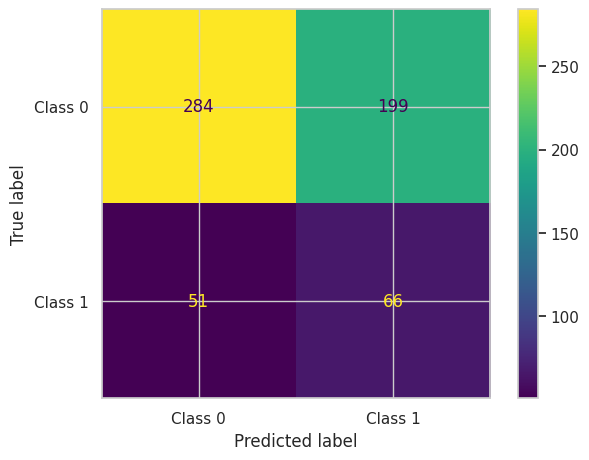

Classification Metrics:
   Metric    Class 0    Class 1  Accuracy Macro-Avg Weighted-Avg ROC-AUC-Score
Precision   0.847761   0.249057  0.583333  0.548409     0.731014      0.650687
   Recall   0.587992   0.564103            0.576047     0.583333              
 F1-Score   0.694377   0.345550            0.519963     0.626355              
  Support 483.000000 117.000000                                               

______________________FOLD 2______________________

19/19 [==============================] - 1s 63ms/step
ROC AUC Score: 0.6619065314717488


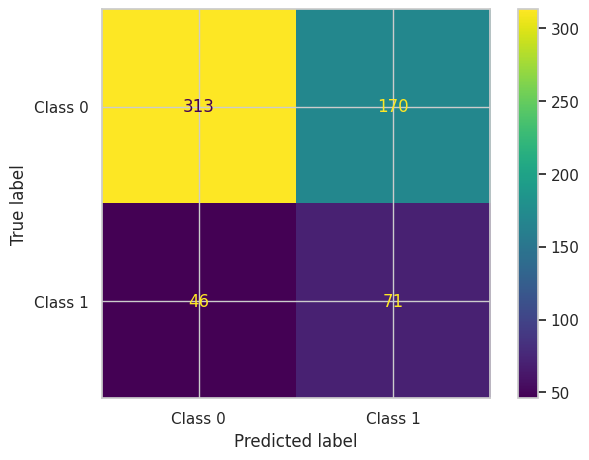

Classification Metrics:
   Metric    Class 0    Class 1 Accuracy Macro-Avg Weighted-Avg ROC-AUC-Score
Precision   0.871866   0.294606     0.64  0.583236     0.759301      0.661907
   Recall   0.648033   0.606838           0.627435         0.64              
 F1-Score   0.743468   0.396648           0.570058     0.675838              
  Support 483.000000 117.000000                                              

______________________FOLD 3______________________

19/19 [==============================] - 1s 58ms/step
ROC AUC Score: 0.6809647679212897


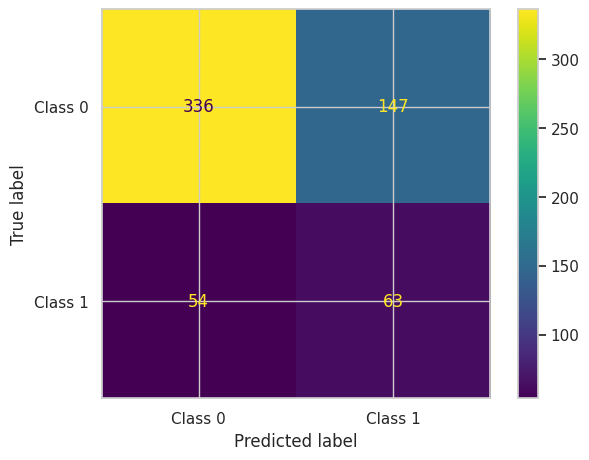

Classification Metrics:
   Metric    Class 0    Class 1 Accuracy Macro-Avg Weighted-Avg ROC-AUC-Score
Precision   0.861538   0.300000    0.665  0.580769     0.752038      0.680965
   Recall   0.695652   0.538462           0.617057        0.665              
 F1-Score   0.769759   0.385321            0.57754     0.694794              
  Support 483.000000 117.000000                                              

______________________FOLD 4______________________

19/19 [==============================] - 1s 59ms/step
ROC AUC Score: 0.6459450372493851


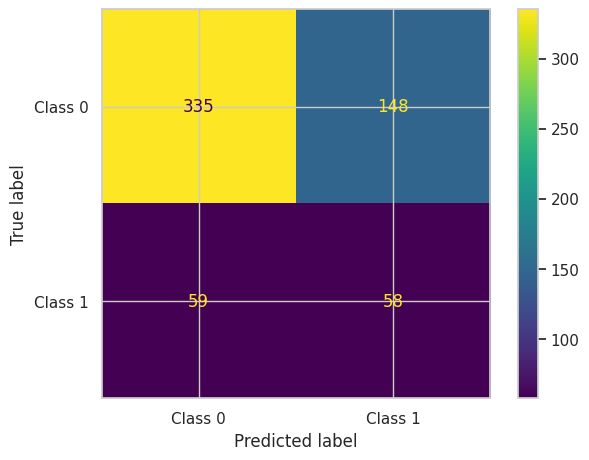

Classification Metrics:
   Metric    Class 0    Class 1 Accuracy Macro-Avg Weighted-Avg ROC-AUC-Score
Precision   0.850254   0.281553    0.655  0.565904     0.739357      0.645945
   Recall   0.693582   0.495726           0.594654        0.655              
 F1-Score   0.763968   0.359133           0.561551     0.685025              
  Support 483.000000 117.000000                                              

______________________FOLD 5______________________



ValueError: axes don't match array

In [19]:
# Example usage with your test data
tfrec_test = tf.io.gfile.glob(['../../../dataset/task1/tf_records/test00.tfrec'])
X_test, y_test = get_dataset(tfrec_test, augment=True, shuffle=True, repeat=False, dim = 224)

model = build_model(dim=224)
for fold in range(4):
    print(f"\n______________________FOLD {fold + 1}______________________\n")
    model.load_weights('efnv2b1_fold-%i.h5' % fold)
    test_evaluate(model, X_test, y_test)
